##Actividad 13

# Preparación de Entorno y Datos
Importamos las librerías necesarias y preparamos el dataset MNIST para simular un escenario de reconstrucción de imágenes mediante la adición de ruido artificial.

In [13]:
import numpy as np # Importa NumPy para operaciones numéricas
import matplotlib.pyplot as plt # Importa Matplotlib para visualizaciones
from tensorflow.keras.datasets import mnist # Importa el dataset MNIST
from tensorflow.keras.layers import Input, Dense # Importa capas para la red neuronal
from tensorflow.keras.models import Model # Importa la clase Model de Keras

print("Librerías importadas correctamente.") # Confirma la carga exitosa

Librerías importadas correctamente.


In [14]:
# Cargar MNIST
(x_train, _), (x_test, _) = mnist.load_data() # Carga imágenes de entrenamiento y prueba (ignora etiquetas)

# Normalización
x_train = x_train.astype('float32') / 255. # Convierte a float y escala píxeles de [0,255] a [0,1]
x_test = x_test.astype('float32') / 255. # Escala los datos de prueba de la misma forma

# Reshape para alimentar a la red densa (aplanar)
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:]))) # Aplana imágenes de 28x28 a vectores de 784
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:]))) # Aplana los datos de prueba

print(f"Forma de entrenamiento: {x_train.shape}") # Muestra las nuevas dimensiones de entrenamiento
print(f"Forma de prueba: {x_test.shape}") # Muestra las nuevas dimensiones de prueba

Forma de entrenamiento: (60000, 784)
Forma de prueba: (10000, 784)


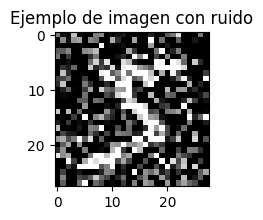

In [15]:
# Generar ruido artificial
noise_factor = 0.5 # Define la intensidad del ruido
x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape) # Suma ruido gaussiano a entrenamiento
x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape) # Suma ruido gaussiano a prueba

# Asegurar que los valores sigan entre 0 y 1
x_train_noisy = np.clip(x_train_noisy, 0., 1.) # Trunca valores fuera del rango [0,1]
x_test_noisy = np.clip(x_test_noisy, 0., 1.) # Trunca valores en el set de prueba

# Visualizar una muestra
plt.figure(figsize=(10, 2)) # Define tamaño de la figura
plt.imshow(x_train_noisy[0].reshape(28, 28), cmap='gray') # Redimensiona a 28x28 y muestra en escala de grises
plt.title("Ejemplo de imagen con ruido") # Añade título a la imagen
plt.show() # Despliega el gráfico

# Arquitectura Base de la Red Neuronal
Definimos un Autoencoder simple.
- **Encoder**: Reduce la dimensionalidad de la entrada (784 px) a una representación latente comprimida.
- **Decoder**: Intenta reconstruir la imagen original a partir del espacio latente.
Utilizaremos capas densas con activación `relu` y una capa de salida con `sigmoid` para mantener los valores de los píxeles entre 0 y 1.

### Conceptos Clave

1. **Autoencoder (El Sistema)**: Es la red completa. Su único trabajo es tomar algo (una imagen con ruido), entender qué es lo importante y tratar de recrearlo lo más parecido al original (sin el ruido).

2. **Encoder (El Compresor)**: Es como un resumidor experto. Toma los 784 píxeles de la imagen y los obliga a pasar por un embudo muy estrecho (el cuello de botella). Para lograrlo, tiene que tirar a la basura lo que no sirve (el ruido) y quedarse solo con la esencia del número.

3. **Decoder (El Reconstructor)**: Solo tiene el resumen del Encoder. Toma esa pequeña pieza de información comprimida y trata de expandirla para volver a dibujar la imagen completa de 784 píxeles. Como no sabe qué ruido había originalmente, solo dibuja el número limpio.

**En resumen:** El Encoder *aprende a ver* y el Decoder *aprende a dibujar*.

In [16]:
# Parámetros de la arquitectura
input_dim = 784  # Define la entrada de 784 neuronas (28x28)
encoding_dim = 32 # Define el tamaño del cuello de botella (compresión)

# Definición del modelo
input_img = Input(shape=(input_dim,)) # Define la capa de entrada con la forma de los datos

# Encoder
encoded = Dense(128, activation='relu')(input_img) # Primera capa densa de reducción con activación ReLU
encoded = Dense(encoding_dim, activation='relu')(encoded) # Capa de compresión final del encoder

# Decoder
decoded = Dense(128, activation='relu')(encoded) # Primera capa de reconstrucción
decoded = Dense(input_dim, activation='sigmoid')(decoded) # Capa de salida con activación Sigmoid para rango [0,1]

# Modelo completo
autoencoder = Model(input_img, decoded) # Crea el objeto del modelo que une entrada y salida

# Compilación
autoencoder.compile(optimizer='adam', loss='binary_crossentropy') # Compila con optimizador Adam y pérdida binaria

autoencoder.summary() # Muestra la tabla con la arquitectura y parámetros

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 209,968 (820.19 KB)

 Trainable params: 209,968 (820.19 KB)

 Non-trainable params: 0 (0.00 B)

### ¿Cómo interpretar la tabla?

La tabla que resume la red neuronal

1. **Layer (type)**: Es el nombre de la capa. Las capas del **Encoder** suelen llamarse `dense` y las del **Decoder** `dense_1`, `dense_2`, etc.
2. **Output Shape**: ¡Esta es la más importante!
   - Nota cómo empieza en `(None, 784)` (la imagen completa).
   - Luego baja a `(None, 128)` y finalmente a `(None, 32)`. ¡Aquí es donde ocurre la **compresión**!
   - Después el Decoder la sube de nuevo hasta `(None, 784)` para reconstruir la imagen.
   - El `None` significa que el modelo puede procesar cualquier cantidad de imágenes a la vez.
3. **Param # (Parámetros)**: Es el número de "neuronas conectadas".
   - Cada parámetro es un valor numérico que la red ajustará durante el entrenamiento.
   - **Regla de oro**: Cuantos más parámetros, más "inteligente" (o compleja) es la red, pero también requiere más memoria y tiempo.
4. **Total params**: La suma de todos los pesos que la red debe aprender para saber diferenciar entre el ruido aleatorio y la forma de un número.

# Entrenar Modelo
Entrenamos el modelo utilizando las imágenes con ruido (`x_train_noisy`) como entrada y las imágenes originales (`x_train`) como objetivo. Esto enseña al autoencoder a ignorar el ruido y recuperar la señal original.

In [17]:
# Configuración del entrenamiento
epochs = 10 # Define cuántas veces la red verá todo el dataset
batch_size = 256 # Define el número de muestras por actualización de gradiente

history = autoencoder.fit( # Inicia el proceso de entrenamiento
    x_train_noisy, x_train, # Entrada: imagen ruidosa, Objetivo: imagen original
    epochs=epochs, # Número de épocas
    batch_size=batch_size, # Tamaño del lote
    shuffle=True, # Mezcla los datos en cada época
    validation_data=(x_test_noisy, x_test) # Evalúa el modelo con datos no vistos durante el entrenamiento
)

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - loss: 0.2595 - val_loss: 0.1890
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - loss: 0.1746 - val_loss: 0.1625
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.1575 - val_loss: 0.1516
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - loss: 0.1491 - val_loss: 0.1447
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.1428 - val_loss: 0.1392
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.1383 - val_loss: 0.1351
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - loss: 0.1345 - val_loss: 0.1323
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.1318 - val_loss: 0.1299
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.1297 - val_loss: 0.1282
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - loss: 0.1279 - val_loss: 0.1272


# Calcular Métricas y Presentar Resultados
Se evalua el rendimiento final en el conjunto de prueba y analizamos la evolución de la pérdida.

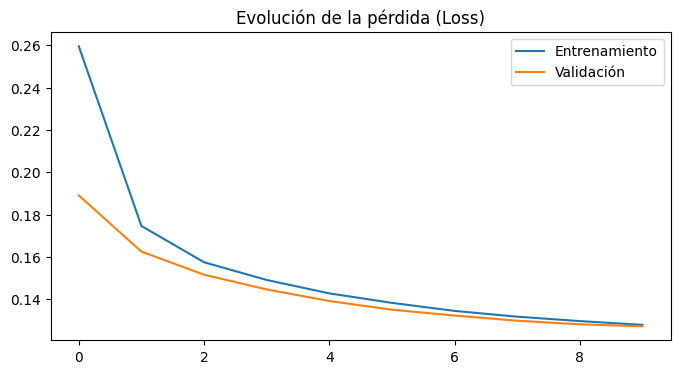

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


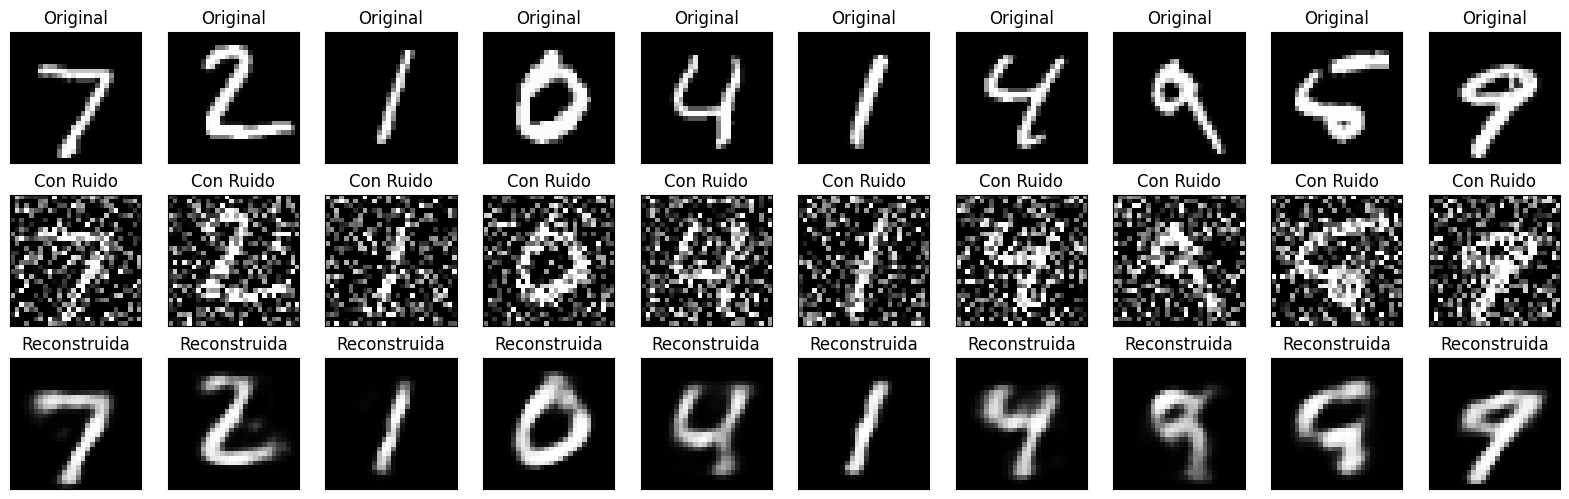

In [18]:
# 5. Gráficos y Visualizaciones

# Gráfico de pérdida
plt.figure(figsize=(8, 4)) # Crea la figura
plt.plot(history.history['loss'], label='Entrenamiento') # Grafica la pérdida de entrenamiento
plt.plot(history.history['val_loss'], label='Validación') # Grafica la pérdida de validación
plt.title('Evolución de la pérdida (Loss)') # Título del gráfico
plt.legend() # Muestra la leyenda
plt.show() # Despliega el gráfico

# Predicción (reconstrucción)
decoded_imgs = autoencoder.predict(x_test_noisy) # Pasa las imágenes ruidosas por el modelo para limpiarlas

# Visualización comparativa
n = 10 # Cantidad de imágenes a mostrar
plt.figure(figsize=(20, 6)) # Define tamaño de la cuadrícula de imágenes
for i in range(n): # Itera sobre las primeras 10 imágenes
    # Original
    ax = plt.subplot(3, n, i + 1) # Define posición en la primera fila
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray') # Muestra original
    plt.title("Original") # Título
    ax.get_xaxis().set_visible(False) # Oculta eje X
    ax.get_yaxis().set_visible(False) # Oculta eje Y

    # Noisy
    ax = plt.subplot(3, n, i + 1 + n) # Define posición en la segunda fila
    plt.imshow(x_test_noisy[i].reshape(28, 28), cmap='gray') # Muestra ruidosa
    plt.title("Con Ruido") # Título
    ax.get_xaxis().set_visible(False) # Oculta eje X
    ax.get_yaxis().set_visible(False) # Oculta eje Y

    # Reconstrucción
    ax = plt.subplot(3, n, i + 1 + 2*n) # Define posición en la tercera fila
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray') # Muestra resultado del autoencoder
    plt.title("Reconstruida") # Título
    ax.get_xaxis().set_visible(False) # Oculta eje X
    ax.get_yaxis().set_visible(False) # Oculta eje Y
plt.show() # Despliega la comparativa final

# Conclusiones

### Comportamiento del Modelo
Durante el entrenamiento, observamos que la **función de pérdida (Loss)** disminuye tanto en los datos de entrenamiento como en los de validación. Esto indica que la red está aprendiendo patrones generales y no simplemente memorizando las imágenes (evitando el *overfitting*). El autoencoder utiliza el **cuello de botella (bottleneck)** para obligar a la red a comprimir la información, quedándose solo con las características esenciales del número y descartando el ruido.

### Calidad de Reconstrucción
Aunque la salida puede verse ligeramente más borrosa que la original, la calidad es notable porque el modelo logra eliminar el factor de ruido del 50%. La activación `sigmoid` en la última capa garantiza que los píxeles se mantengan en el rango [0, 1], mientras que la pérdida `binary_crossentropy` es efectiva para comparar la similitud estadística entre la imagen original y la reconstruida.

### Aplicaciones Reales de los Autoencoders
Esta tecnología no solo sirve para limpiar imágenes de números; en la industria se utiliza para:
1.  **Denoising (Eliminación de Ruido):** Limpiar grabaciones de audio o imágenes médicas (como Rayos X) con interferencias.
2.  **Detección de Anomalías:** Si una red se entrena solo con datos "normales", cualquier dato con un error de reconstrucción muy alto puede identificarse como un fallo (ej. transacciones bancarias fraudulentas).
3.  **Compresión de Datos:** Reducir el tamaño de archivos manteniendo la información semántica más importante.
4.  **Generación de Datos:** Variantes como los VAE (Variational Autoencoders) se usan para crear caras o paisajes realistas desde cero.